In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

In [4]:
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv(r"C:\Users\Ronit Shaw\Downloads\archive\Loan_Default pre processed csv.csv")
df.head()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,...,age_35-44,age_45-54,age_55-64,age_65-74,age_<25,age_>74,submission_of_application_to_inst,Region_North-East,Region_central,Region_south
0,24892,2019,406500,4.560,0.2000,595.0,360.0,508000.0,9480.0,834,...,True,False,False,False,False,False,True,False,False,True
1,24894,2019,696500,4.000,0.3042,0.0,360.0,758000.0,10440.0,602,...,False,False,False,False,False,False,False,False,False,False
2,24895,2019,706500,3.990,0.1523,370.0,360.0,1008000.0,10080.0,864,...,True,False,False,False,False,False,False,False,False,False
3,24896,2019,346500,4.500,0.9998,5120.0,360.0,438000.0,5040.0,860,...,False,False,True,False,False,False,True,False,False,False
4,24898,2019,376500,4.875,0.7395,1150.0,360.0,478000.0,5580.0,580,...,False,False,True,False,False,False,True,False,True,False


In [6]:
df.columns

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1', 'loan_limit_ncf', 'Gender_Joint',
       'Gender_Male', 'Gender_Sex Not Available', 'approv_in_adv_pre',
       'loan_type_type2', 'loan_type_type3', 'loan_purpose_p2',
       'loan_purpose_p3', 'loan_purpose_p4', 'Credit_Worthiness_l2',
       'business_or_commercial_nob/c', 'Neg_ammortization_not_neg',
       'interest_only_not_int', 'lump_sum_payment_not_lpsm',
       'occupancy_type_pr', 'occupancy_type_sr', 'total_units_2U',
       'total_units_3U', 'total_units_4U', 'credit_type_CRIF',
       'credit_type_EQUI', 'credit_type_EXP', 'co-applicant_credit_type_EXP',
       'age_35-44', 'age_45-54', 'age_55-64', 'age_65-74', 'age_<25',
       'age_>74', 'submission_of_application_to_inst', 'Region_North-East',
       'Region_central', 'Region_south'],
      dtype='object')

In [7]:
target = "loan_amount"

In [8]:
X = df.drop(target, axis=1)
y = df[target]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# ==========================================
# MILESTONE 3 – Logistic Regression Baseline
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------------
# 1. Convert Target to Binary
# -------------------------

df["loan_amount_binary"] = (df["loan_amount"] > df["loan_amount"].median()).astype(int)

X = df.drop(["loan_amount", "loan_amount_binary"], axis=1)
y = df["loan_amount_binary"]

# -------------------------
# 2. Train-Test Split (ONLY ONCE)
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 3. Standardization
# -------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 4. Train Logistic Regression
# -------------------------

lr_model = LogisticRegression(max_iter=5000, solver='liblinear')
lr_model.fit(X_train_scaled, y_train)

# -------------------------
# 5. Evaluation
# -------------------------

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("===== Logistic Regression Baseline =====")
print("Accuracy:", round(lr_accuracy, 4))
print("AUC-ROC:", round(lr_auc, 4))

===== Logistic Regression Baseline =====
Accuracy: 0.9466
AUC-ROC: 0.9869


In [11]:
# Split first
X = df.drop(target, axis=1)
y = df[target]
    
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# ==========================================
# FULL ML PIPELINE: Milestone 3 + 4
# Logistic Regression + XGBoost + LightGBM
# ==========================================

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# -------------------------
# 1️⃣ PREPARE DATA
# -------------------------

# Convert target to binary: High/Low loan amount
df["loan_amount_binary"] = (df["loan_amount"] > df["loan_amount"].median()).astype(int)

X = df.drop(["loan_amount", "loan_amount_binary"], axis=1)
y = df["loan_amount_binary"]

# Train-test split (only once)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 2️⃣ CLEAN COLUMN NAMES FOR TREE MODELS
# -------------------------
X_train = X_train.copy()
X_test = X_test.copy()

X_train.columns = [str(c).replace(" ", "_").replace("<","").replace(">","").replace("[","").replace("]","") for c in X_train.columns]
X_test.columns = [str(c).replace(" ", "_").replace("<","").replace(">","").replace("[","").replace("]","") for c in X_test.columns]

# -------------------------
# 3️⃣ SCALING FOR LOGISTIC REGRESSION
# -------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 4️⃣ MILESTONE 3: LOGISTIC REGRESSION
# -------------------------
lr_model = LogisticRegression(max_iter=5000, solver='liblinear')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("===== Logistic Regression Baseline =====")
print("Accuracy:", round(lr_accuracy, 4))
print("AUC-ROC:", round(lr_auc, 4))

# -------------------------
# 5️⃣ MILESTONE 4: XGBOOST
# -------------------------
xgb = XGBClassifier(eval_metric='logloss', random_state=42)  # Removed use_label_encoder

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("\n===== XGBoost Results =====")
print("Best Params:", xgb_grid.best_params_)
print("AUC-ROC:", round(xgb_auc, 4))

# -------------------------
# 6️⃣ MILESTONE 4: LIGHTGBM
# -------------------------
lgbm = LGBMClassifier(random_state=42)

lgbm_params = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 5],
    'learning_rate': [0.05, 0.1]
}

lgbm_grid = GridSearchCV(
    lgbm,
    lgbm_params,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

lgbm_grid.fit(X_train, y_train)

best_lgbm = lgbm_grid.best_estimator_
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, y_prob_lgbm)

print("\n===== LightGBM Results =====")
print("Best Params:", lgbm_grid.best_params_)
print("AUC-ROC:", round(lgbm_auc, 4))

# -------------------------
# 7️⃣ FINAL COMPARISON
# -------------------------
print("\n===== MODEL COMPARISON =====")
print("Logistic Regression AUC:", round(lr_auc, 4))
print("XGBoost AUC:", round(xgb_auc, 4))
print("LightGBM AUC:", round(lgbm_auc, 4))

===== Logistic Regression Baseline =====
Accuracy: 0.9466
AUC-ROC: 0.9869

===== XGBoost Results =====
Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
AUC-ROC: 1.0
[LightGBM] [Info] Number of positive: 38005, number of negative: 40544
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003585 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2019
[LightGBM] [Info] Number of data points in the train set: 78549, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.483838 -> initscore=-0.064670
[LightGBM] [Info] Start training from score -0.064670

===== LightGBM Results =====
Best Params: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 200}
AUC-ROC: 1.0

===== MODEL COMPARISON =====
Logistic Regression AUC: 0.9869
XGBoost AUC: 1.0
LightGBM AUC: 1.0


In [13]:
from sklearn.metrics import cohen_kappa_score

# Logistic Regression
kappa_lr = cohen_kappa_score(y_test, y_pred_lr)

# XGBoost
y_pred_xgb = best_xgb.predict(X_test)
kappa_xgb = cohen_kappa_score(y_test, y_pred_xgb)

# LightGBM
y_pred_lgbm = best_lgbm.predict(X_test)
kappa_lgbm = cohen_kappa_score(y_test, y_pred_lgbm)

# Print results
print("===== Cohen's Kappa Scores =====")
print("Logistic Regression Kappa:", round(kappa_lr, 4))
print("XGBoost Kappa:", round(kappa_xgb, 4))
print("LightGBM Kappa:", round(kappa_lgbm, 4))

===== Cohen's Kappa Scores =====
Logistic Regression Kappa: 0.8931
XGBoost Kappa: 0.9982
LightGBM Kappa: 0.9984


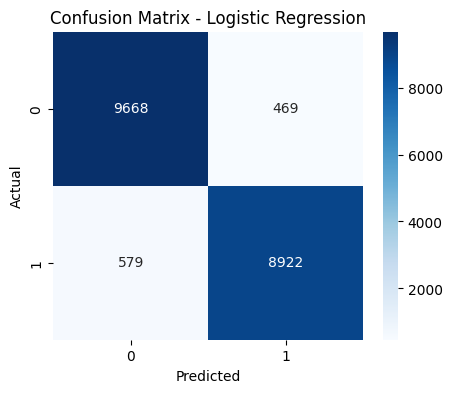

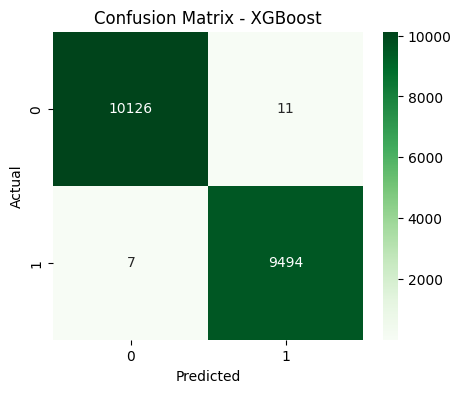

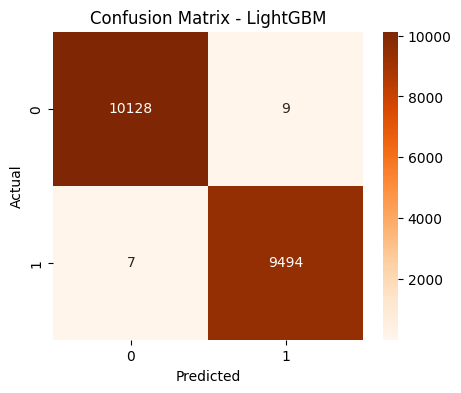

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ Logistic Regression
# -------------------------
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# 2️⃣ XGBoost
# -------------------------
y_pred_xgb = best_xgb.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------
# 3️⃣ LightGBM
# -------------------------
y_pred_lgbm = best_lgbm.predict(X_test)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
print("Logistic Regression AUC:", round(lr_auc, 4))
print("XGBoost AUC:", round(xgb_auc, 4))
print("LightGBM AUC:", round(lgbm_auc, 4))

Logistic Regression AUC: 0.9869
XGBoost AUC: 1.0
LightGBM AUC: 1.0


In [16]:
print("Accuracy:", round(lr_accuracy, 4))

Accuracy: 0.9466


In [17]:
from sklearn.metrics import accuracy_score, roc_auc_score

# ===============================
# 1️⃣ XGBoost Evaluation
# ===============================

# Predictions
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("===== XGBoost Performance =====")
print("Accuracy:", round(accuracy_xgb, 4))
print("AUC-ROC:", round(auc_xgb, 4))


# ===============================
# 2️⃣ LightGBM Evaluation
# ===============================

# Predictions
y_pred_lgbm = best_lgbm.predict(X_test)
y_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

# Metrics
accuracy_lgbm = accuracy_score(y_test, y_pred_lgbm)
auc_lgbm = roc_auc_score(y_test, y_prob_lgbm)

print("\n===== LightGBM Performance =====")
print("Accuracy:", round(accuracy_lgbm, 4))
print("AUC-ROC:", round(auc_lgbm, 4))

===== XGBoost Performance =====
Accuracy: 0.9991
AUC-ROC: 1.0

===== LightGBM Performance =====
Accuracy: 0.9992
AUC-ROC: 1.0


In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score

# ===============================
# XGBoost Overfitting Check
# ===============================

# Train performance
y_train_pred_xgb = best_xgb.predict(X_train)
y_train_prob_xgb = best_xgb.predict_proba(X_train)[:, 1]

train_acc_xgb = accuracy_score(y_train, y_train_pred_xgb)
train_auc_xgb = roc_auc_score(y_train, y_train_prob_xgb)

# Test performance
y_test_pred_xgb = best_xgb.predict(X_test)
y_test_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

test_acc_xgb = accuracy_score(y_test, y_test_pred_xgb)
test_auc_xgb = roc_auc_score(y_test, y_test_prob_xgb)

print("===== XGBoost =====")
print("Train Accuracy:", round(train_acc_xgb,4))
print("Test Accuracy :", round(test_acc_xgb,4))
print("Train AUC:", round(train_auc_xgb,4))
print("Test AUC :", round(test_auc_xgb,4))


# ===============================
# LightGBM Overfitting Check
# ===============================

# Train performance
y_train_pred_lgbm = best_lgbm.predict(X_train)
y_train_prob_lgbm = best_lgbm.predict_proba(X_train)[:, 1]

train_acc_lgbm = accuracy_score(y_train, y_train_pred_lgbm)
train_auc_lgbm = roc_auc_score(y_train, y_train_prob_lgbm)

# Test performance
y_test_pred_lgbm = best_lgbm.predict(X_test)
y_test_prob_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

test_acc_lgbm = accuracy_score(y_test, y_test_pred_lgbm)
test_auc_lgbm = roc_auc_score(y_test, y_test_prob_lgbm)

print("\n===== LightGBM =====")
print("Train Accuracy:", round(train_acc_lgbm,4))
print("Test Accuracy :", round(test_acc_lgbm,4))
print("Train AUC:", round(train_auc_lgbm,4))
print("Test AUC :", round(test_auc_lgbm,4))

===== XGBoost =====
Train Accuracy: 0.9998
Test Accuracy : 0.9991
Train AUC: 1.0
Test AUC : 1.0

===== LightGBM =====
Train Accuracy: 1.0
Test Accuracy : 0.9992
Train AUC: 1.0
Test AUC : 1.0


In [19]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("Overlap rows:",
      len(set(X_train.index).intersection(set(X_test.index))))

Train size: (78549, 46)
Test size: (19638, 46)
Overlap rows: 0
